# Notebook 08 — SVM (LinearSVC)
**Desempenho Socioeconômico no ENEM (2012–2024)**

Treino e avaliação de **LinearSVC** com grid search simples sobre C e class_weight.
Mesma amostra e split do notebook 06 (500k, 3 classes, 60/20/20).

| Seção | Conteúdo |
|---|---|
| 0 | Setup |
| 1 | Carregamento via DuckDB |
| 2 | Pré-processamento e split |
| 3 | Grid search — Modelo M1 (ENEM only) |
| 4 | Grid search — Modelo M2 (ENEM + IDHM) |
| 5 | Modelos finais, figuras e comparação |
| 6 | Persistência |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import duckdb

from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
N_SAMPLE     = 500_000

DATA_DIR   = '../data/processed'
MODELS_DIR = '../data/models'
FIGS_DIR   = DATA_DIR
PARQUET    = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# Grid de hiperparâmetros
C_GRID      = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
WEIGHT_GRID = [None, 'balanced']

print('Setup OK')
print(f'  C_GRID = {C_GRID}')
print(f'  class_weight = {WEIGHT_GRID}')
print(f'  Combinações: {len(C_GRID) * len(WEIGHT_GRID)}')

Setup OK
  C_GRID = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
  class_weight = [None, 'balanced']
  Combinações: 16


## Seção 1 — Carregamento via DuckDB

In [2]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400', '400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,} registros')
print('Distribuição y_mt:')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 139,027 registros
Distribuição y_mt:
  Baixo (<500): 72,719 (52.3%)
  Médio (500–700): 56,457 (40.6%)
  Alto (>700): 9,851 (7.1%)


## Seção 2 — Pré-processamento e Split

In [3]:
SEXO_MAP   = {'F': 0, '0': 0, 'M': 1, '1': 1}
LETTER_MAP = {c: i for i, c in enumerate('ABCDEFGHI')}
INCOME_MAP = {c: i for i, c in enumerate('ABCDE')}
REGIAO_MAP = {'Norte': 0, 'Nordeste': 1, 'Centro-Oeste': 2, 'Sul': 3, 'Sudeste': 4}

df['tp_sexo']   = df['TP_SEXO'].map(SEXO_MAP)
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'], errors='coerce')
df['q001']      = df['Q001'].map(LETTER_MAP)
df['q002']      = df['Q002'].map(LETTER_MAP)
df['q006']      = df['Q006_HARM'].map(INCOME_MAP)
df['regiao']    = df['REGIAO'].map(REGIAO_MAP)
df['ano']       = df['NU_ANO'].astype('float32')

def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo', 'tp_cor', 'tp_escola', 'q001', 'q002', 'q006', 'regiao', 'ano']
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai', 'q_ocup_mae', 'q_n_pessoas', 'q_empregada',
    'q_carro', 'q_moto', 'q_geladeira', 'q_lavadora', 'q_tv',
    'q_computador', 'q_internet', 'q_celular', 'q_tipo_esc_em', 'q_bolsa_fam'
]
FEATS_M1 = FEATS_BASE
FEATS_M2 = FEATS_BASE + FEATS_IDHM
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT

X_m1 = df[FEATS_M1].values.astype('float32')
X_m2 = df[FEATS_M2].values.astype('float32')
X_m3 = df[FEATS_M3].values.astype('float32')
X_m4 = df[FEATS_M4].values.astype('float32')
y    = df['y_mt'].values.astype('int8')
del df; gc.collect()

# Split 60/20/20 estratificado
(Xm1_tmp, Xm1_test, Xm2_tmp, Xm2_test,
 Xm3_tmp, Xm3_test, Xm4_tmp, Xm4_test,
 y_tmp, y_test) = train_test_split(
    X_m1, X_m2, X_m3, X_m4, y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
(Xm1_tr, Xm1_val, Xm2_tr, Xm2_val,
 Xm3_tr, Xm3_val, Xm4_tr, Xm4_val,
 y_tr, y_val) = train_test_split(
    Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp,
    test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE
)
del Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp; gc.collect()

print(f'Treino: {len(y_tr):,} | Val: {len(y_val):,} | Teste: {len(y_test):,} [SELADO]')
print(f'M1={len(FEATS_M1)} | M2={len(FEATS_M2)} | M3={len(FEATS_M3)} | M4={len(FEATS_M4)} features')


Treino: 83,415 | Val: 27,806 | Teste: 27,806 [SELADO]
M1=8 | M2=17 | M3=22 | M4=31 features


In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(Xm1_tr, y_tr)
yp_dummy = dummy.predict(Xm1_val)

baseline = {
    'Accuracy'   : accuracy_score(y_val, yp_dummy),
    'Macro F1'   : f1_score(y_val, yp_dummy, average='macro'),
    'Weighted F1': f1_score(y_val, yp_dummy, average='weighted'),
}
print('Baseline (majority):')
for k, v in baseline.items():
    print(f'  {k:<15s}: {v:.4f}')

Baseline (majority):
  Accuracy       : 0.5231
  Macro F1       : 0.2289
  Weighted F1    : 0.3593


## Seção 3 — Grid Search: Modelo M1 (ENEM only)

In [5]:
def make_svm(C, class_weight=None):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('svm',     LinearSVC(C=C, class_weight=class_weight,
                              max_iter=2000, random_state=RANDOM_STATE))
    ])

def grid_search(X_tr, X_v, y_tr, y_v, label=''):
    print(f'  {"C":>8s}  {"weight":>10s}  {"Accuracy":>9s}  {"Macro F1":>9s}  {"Weighted F1":>11s}')
    print('  ' + '-' * 55)
    results = {}
    for cw in WEIGHT_GRID:
        for C in C_GRID:
            pipe = make_svm(C, cw)
            pipe.fit(X_tr, y_tr)
            yp = pipe.predict(X_v)
            results[(C, cw)] = {
                'acc'        : accuracy_score(y_v, yp),
                'f1_macro'   : f1_score(y_v, yp, average='macro'),
                'f1_weighted': f1_score(y_v, yp, average='weighted'),
            }
            r = results[(C, cw)]
            cw_str = str(cw) if cw else 'None'
            print(f'  {C:>8.3f}  {cw_str:>10s}  {r["acc"]:>9.4f}  '
                  f'{r["f1_macro"]:>9.4f}  {r["f1_weighted"]:>11.4f}')
    best = max(results, key=lambda p: results[p]['f1_macro'])
    print(f'\n  Melhor (Macro F1): C={best[0]}, class_weight={best[1]}  '
          f'→  F1={results[best]["f1_macro"]:.4f}')
    return results, best

print('=== Grid Search M1 (ENEM only) ===')
res_m1, best_m1 = grid_search(Xm1_tr, Xm1_val, y_tr, y_val)

=== Grid Search M1 (ENEM only) ===
         C      weight   Accuracy   Macro F1  Weighted F1
  -------------------------------------------------------
     0.001        None     0.5835     0.3845       0.5498
     0.010        None     0.5834     0.3844       0.5496
     0.100        None     0.5834     0.3844       0.5496
     0.500        None     0.5834     0.3844       0.5496
     1.000        None     0.5834     0.3844       0.5496
     5.000        None     0.5834     0.3844       0.5496
    10.000        None     0.5834     0.3844       0.5496
    50.000        None     0.5834     0.3844       0.5496
     0.001    balanced     0.5402     0.4660       0.5313
     0.010    balanced     0.5402     0.4658       0.5311
     0.100    balanced     0.5402     0.4658       0.5311
     0.500    balanced     0.5402     0.4659       0.5311
     1.000    balanced     0.5402     0.4659       0.5311
     5.000    balanced     0.5402     0.4659       0.5311
    10.000    balanced     0.5402    

## Seção 4 — Grid Search: Modelo M2 (ENEM + IDHM)

In [6]:
print('=== Grid Search M2 (ENEM + IDHM) ===')
res_m2, best_m2 = grid_search(Xm2_tr, Xm2_val, y_tr, y_val)

=== Grid Search M2 (ENEM + IDHM) ===
         C      weight   Accuracy   Macro F1  Weighted F1
  -------------------------------------------------------
     0.001        None     0.5836     0.3845       0.5498
     0.010        None     0.5842     0.3850       0.5505
     0.100        None     0.5845     0.3850       0.5505
     0.500        None     0.5846     0.3851       0.5506
     1.000        None     0.5846     0.3851       0.5506
     5.000        None     0.5848     0.3852       0.5508
    10.000        None     0.5846     0.3851       0.5506
    50.000        None     0.5847     0.3851       0.5507
     0.001    balanced     0.5448     0.4708       0.5365
     0.010    balanced     0.5444     0.4705       0.5361
     0.100    balanced     0.5449     0.4709       0.5366
     0.500    balanced     0.5452     0.4714       0.5370
     1.000    balanced     0.5450     0.4712       0.5367
     5.000    balanced     0.5452     0.4717       0.5370
    10.000    balanced     0.5452  

## Seção 5 — Modelos Finais, Figuras e Comparação

In [7]:
best_C_m1, best_cw_m1 = best_m1
best_C_m2, best_cw_m2 = best_m2

pipe_m1 = make_svm(best_C_m1, best_cw_m1)
pipe_m1.fit(Xm1_tr, y_tr)
yp_m1 = pipe_m1.predict(Xm1_val)

pipe_m2 = make_svm(best_C_m2, best_cw_m2)
pipe_m2.fit(Xm2_tr, y_tr)
yp_m2 = pipe_m2.predict(Xm2_val)

m1_metrics = {
    'Accuracy'   : accuracy_score(y_val, yp_m1),
    'Macro F1'   : f1_score(y_val, yp_m1, average='macro'),
    'Weighted F1': f1_score(y_val, yp_m1, average='weighted'),
}
m2_metrics = {
    'Accuracy'   : accuracy_score(y_val, yp_m2),
    'Macro F1'   : f1_score(y_val, yp_m2, average='macro'),
    'Weighted F1': f1_score(y_val, yp_m2, average='weighted'),
}

print('Classification Report — M1:')
print(classification_report(y_val, yp_m1, target_names=FAIXA_ORDER))

print('Classification Report — M2:')
print(classification_report(y_val, yp_m2, target_names=FAIXA_ORDER))

Classification Report — M1:
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.48      0.31      0.38     11292
    Alto (>700)       0.25      0.53      0.34      1970

       accuracy                           0.54     27806
      macro avg       0.46      0.52      0.47     27806
   weighted avg       0.55      0.54      0.53     27806

Classification Report — M2:
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.49      0.32      0.39     11292
    Alto (>700)       0.26      0.54      0.35      1970

       accuracy                           0.55     27806
      macro avg       0.46      0.53      0.47     27806
   weighted avg       0.55      0.55      0.54     27806



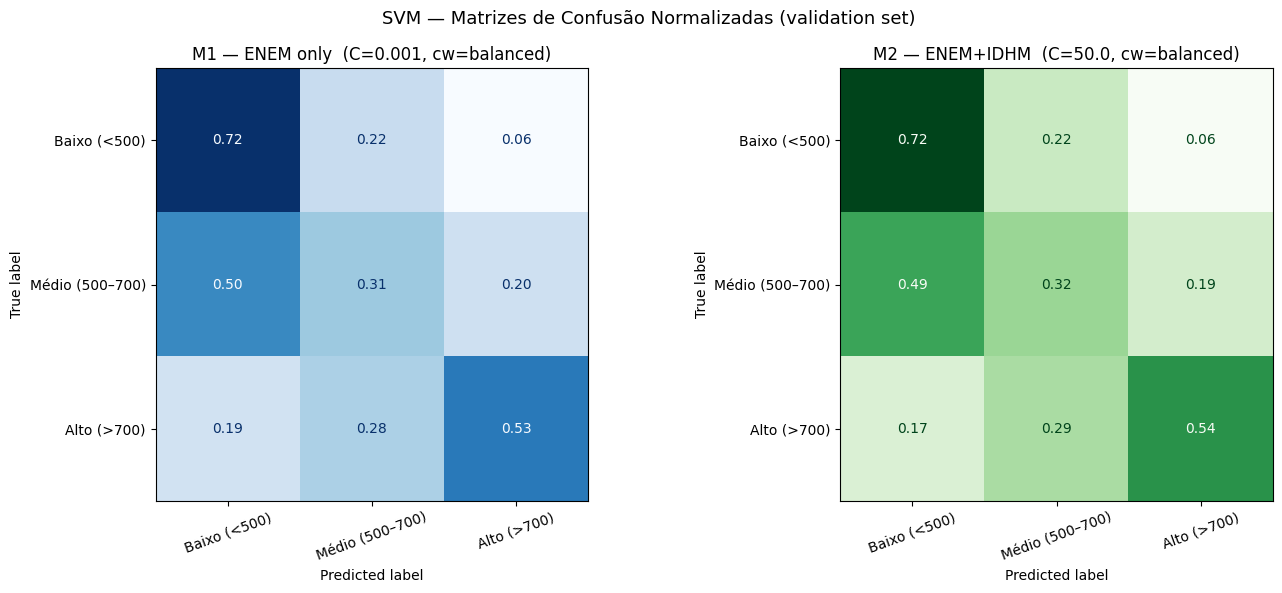

Figura salva: fig_svm_cm.png


In [8]:
cm_m1 = confusion_matrix(y_val, yp_m1, normalize='true')
cm_m2 = confusion_matrix(y_val, yp_m2, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, cmap in zip(
    axes,
    [cm_m1, cm_m2],
    [f'M1 — ENEM only  (C={best_C_m1}, cw={best_cw_m1})',
     f'M2 — ENEM+IDHM  (C={best_C_m2}, cw={best_cw_m2})'],
    ['Blues', 'Greens']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('SVM — Matrizes de Confusão Normalizadas (validation set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_svm_cm.png', dpi=150)
plt.show()
print('Figura salva: fig_svm_cm.png')

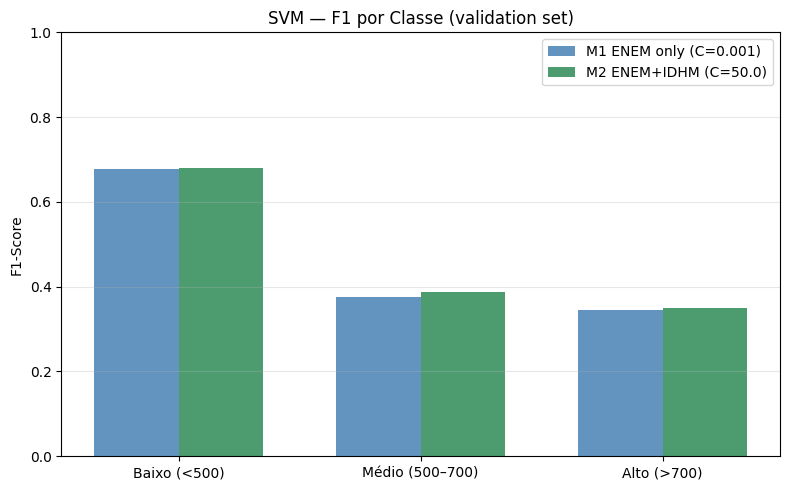

Figura salva: fig_svm_f1_classe.png


In [9]:
f1_m1 = f1_score(y_val, yp_m1, average=None, labels=[0, 1, 2])
f1_m2 = f1_score(y_val, yp_m2, average=None, labels=[0, 1, 2])

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1_m1, w, label=f'M1 ENEM only (C={best_C_m1})', color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_m2, w, label=f'M2 ENEM+IDHM (C={best_C_m2})', color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('SVM — F1 por Classe (validation set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_svm_f1_classe.png', dpi=150)
plt.show()
print('Figura salva: fig_svm_f1_classe.png')

In [10]:
rows = [
    ('Baseline (majority)', '—', '—',
     baseline['Accuracy'], baseline['Macro F1'], baseline['Weighted F1']),
    (f'SVM M1 — ENEM only', best_C_m1, str(best_cw_m1),
     m1_metrics['Accuracy'], m1_metrics['Macro F1'], m1_metrics['Weighted F1']),
    (f'SVM M2 — ENEM+IDHM', best_C_m2, str(best_cw_m2),
     m2_metrics['Accuracy'], m2_metrics['Macro F1'], m2_metrics['Weighted F1']),
]
df_res = pd.DataFrame(rows,
    columns=['Modelo', 'C', 'class_weight', 'Accuracy', 'Macro F1', 'Weighted F1'])

print('=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===')
print(df_res.to_string(index=False))

delta = m2_metrics['Macro F1'] - m1_metrics['Macro F1']
print(f'\nΔ Macro F1 (M2 − M1): {delta:+.4f}')

=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===
             Modelo      C class_weight  Accuracy  Macro F1  Weighted F1
Baseline (majority)      —            —  0.523053  0.228949     0.359257
 SVM M1 — ENEM only  0.001     balanced  0.540243  0.465989     0.531254
 SVM M2 — ENEM+IDHM   50.0     balanced  0.545242  0.471676     0.537052

Δ Macro F1 (M2 − M1): +0.0057


## Seção 6 — Persistência

In [11]:
joblib.dump(pipe_m1, f'{MODELS_DIR}/svm_enem_only_faixa_mt.pkl')
joblib.dump(pipe_m2, f'{MODELS_DIR}/svm_enem_idhm_faixa_mt.pkl')
print('Modelos salvos:')
print(f'  {MODELS_DIR}/svm_enem_only_faixa_mt.pkl')
print(f'  {MODELS_DIR}/svm_enem_idhm_faixa_mt.pkl')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))
print('\n* Test set selado em data/models/test_sets_selados.pkl')

Modelos salvos:
  ../data/models/svm_enem_only_faixa_mt.pkl
  ../data/models/svm_enem_idhm_faixa_mt.pkl

=== RESUMO FINAL ===
             Modelo      C class_weight  Accuracy  Macro F1  Weighted F1
Baseline (majority)      —            —  0.523053  0.228949     0.359257
 SVM M1 — ENEM only  0.001     balanced  0.540243  0.465989     0.531254
 SVM M2 — ENEM+IDHM   50.0     balanced  0.545242  0.471676     0.537052

* Test set selado em data/models/test_sets_selados.pkl
